# Making Large Models Smaller: Quantization


## 1. The problem:

A neural network is mostly a long list of numbers called **weights** (or parameters).
Each weight is normally stored as a 32-bit floating-point number (FP32), which takes 4 bytes.
So the memory a model needs is:

$$\text{size (bytes)} = N_{\text{params}} \times \frac{b}{8}$$

where $N_{\text{params}}$ is the number of parameters and $b$ is the number of bits per parameter.

For example, BERT-base has $110 \times 10^6$ parameters:

$$110 \times 10^6 \times \frac{32}{8} = 440 \times 10^6 \text{ bytes} \approx 440 \text{ MB}$$

LLaMA models are much bigger. Llama 3 8B has $8 \times 10^9$ parameters, which is **32 GB** in FP32.
This causes several problems:

- **Memory:** the model may not fit in RAM or GPU memory (a laptop with 24 GB cannot load it).
- **Speed:** moving billions of numbers through memory makes every prediction slow.
- **Cost and energy:** bigger models need bigger and more expensive hardware.
- **Devices:** phones and small devices cannot run them at all.

The table and graph below show the size of some models at different precisions.


,FP32,FP16,INT8,INT4
DistilBERT,0.26,0.13,0.07,0.03
BERT-base,0.44,0.22,0.11,0.06
Llama 3 8B,32.00,16.00,8.00,4.00
Llama 3 70B,280.00,140.00,70.00,35.00


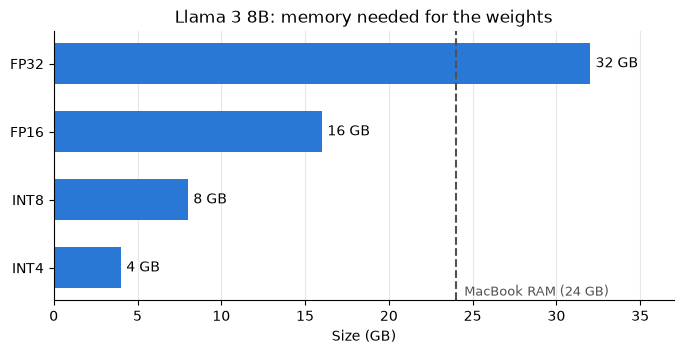

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

parameters = {
    "DistilBERT": 66e6,
    "BERT-base": 110e6,
    "Llama 3 8B": 8e9,
    "Llama 3 70B": 70e9,
}
bits_per_number = {"FP32": 32, "FP16": 16, "INT8": 8, "INT4": 4}

# size in GB = parameters x bits / 8 (bits to bytes) / 1e9 (bytes to GB)
sizes = pd.DataFrame({
    precision: {model: count * bits / 8 / 1e9 for model, count in parameters.items()}
    for precision, bits in bits_per_number.items()
})
display(sizes.round(2))

llama_sizes = sizes.loc["Llama 3 8B"]
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(llama_sizes.index, llama_sizes.values, color="#2a78d6", height=0.6)
ax.invert_yaxis()
ax.bar_label(bars, labels=[f"{v:.0f} GB" for v in llama_sizes.values], padding=4)

ax.axvline(24, color="#52514e", linestyle="--", linewidth=1.5)
ax.text(24.5, 3.35, "MacBook RAM (24 GB)", color="#52514e", fontsize=9, va="center")

ax.set_title("Llama 3 8B: memory needed for the weights")
ax.set_xlabel("Size (GB)")
ax.set_xlim(0, 37)
ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.show()


## 2. Ways to make a model smaller

There are four main families of model compression methods.

### 2.1 Pruning
Many weights are very close to zero and have almost no effect on the output. Pruning removes them.
A common rule is magnitude pruning: remove every weight whose absolute value is below a threshold $\tau$:

$$w_i' = \begin{cases} w_i & \text{if } |w_i| \geq \tau \\ 0 & \text{otherwise} \end{cases}$$

Removing single weights (unstructured pruning) only saves memory if the hardware supports sparse matrices.
Removing whole neurons, heads or layers (structured pruning) makes the model really smaller, but hurts accuracy more.

### 2.2 Knowledge distillation
A small **student** model is trained to copy the output probabilities of a large **teacher** model.
Both use a softmax with temperature $T$ (the same temperature as in LLM sampling), which makes the probabilities softer so the student also learns which wrong answers are "almost right":

$$p_i^{(T)} = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

$$\mathcal{L} = \alpha \, \mathcal{L}_{CE}\big(y, \, p_{\text{student}}\big) + (1 - \alpha) \, T^2 \, \mathrm{KL}\big(p_{\text{teacher}}^{(T)} \,\|\, p_{\text{student}}^{(T)}\big)$$

The first part learns from the true labels $y$, the second part learns from the teacher.
**DistilBERT** was made this way: it is 40% smaller and 60% faster than BERT and keeps 97% of its language understanding (Sanh et al., 2019).

### 2.3 Low-rank factorization
A weight matrix $W$ of size $m \times n$ is replaced by two thin matrices $A$ ($m \times r$) and $B$ ($r \times n$), with a small rank $r$:

$$W \approx A B, \qquad \text{parameters: } m \cdot n \;\rightarrow\; r \, (m + n)$$

For a $768 \times 768$ BERT layer with $r = 64$: $589{,}824 \rightarrow 98{,}304$ parameters (6 times fewer).
LoRA uses the same idea, but to fine-tune a model cheaply, not to shrink it.

### 2.4 Quantization
Every weight is kept, but stored with fewer bits (for example 8 or 4 instead of 32).

| Method | What changes | Retraining needed? | Typical size reduction |
|---|---|---|---|
| Pruning | number of weights | usually a short fine-tune | depends on sparsity support |
| Distillation | the architecture (a new, smaller model) | yes, the student is trained | 40% for DistilBERT |
| Low-rank | the shape of the weight matrices | usually a short fine-tune | depends on the rank $r$ |
| **Quantization** | **bits per weight** | **often no** | **2× (FP16), 4× (INT8), 8× (INT4)** |

**Why this research focuses on quantization:** it works on an already trained model, often without retraining,
it works for any architecture, its savings are large and predictable, and it can be combined with the other methods
(for example, a distilled model can also be quantized). It is also the main way large models such as LLaMA are run on laptops.


## 3. How quantization works

### 3.1 Number formats

| Format | Type | Bits | Bytes per number | Values / precision |
|---|---|---|---|---|
| FP32 | floating point | 32 | 4 | about 7 significant digits (normal training format) |
| FP16 | floating point | 16 | 2 | about 3 significant digits, max 65,504 |
| INT8 | integer | 8 | 1 | 256 values: $-128$ to $127$ |
| INT4 | integer | 4 | 0.5 | 16 values: $-8$ to $7$ |

A $b$-bit integer can take $2^b$ values. Quantization maps the real weights onto these few integers using a **scale** $s$.

### 3.2 Symmetric quantization
The range is centred on zero. With $q_{\max} = 2^{b-1} - 1$ (127 for INT8, 7 for INT4):

$$s = \frac{\max |x|}{q_{\max}}, \qquad q = \mathrm{clip}\!\left(\mathrm{round}\!\left(\frac{x}{s}\right), \, -q_{\max}, \, q_{\max}\right), \qquad \hat{x} = s \cdot q$$

Only the integers $q$ and the scale $s$ are stored. $\hat{x}$ is the value we get back (dequantization).

### 3.3 Asymmetric quantization
For values that are not centred on zero (for example activations after ReLU, which are all $\geq 0$), a **zero-point** $z$ shifts the range:

$$s = \frac{x_{\max} - x_{\min}}{2^b - 1}, \qquad z = \mathrm{round}\!\left(-\frac{x_{\min}}{s}\right), \qquad q = \mathrm{clip}\!\left(\mathrm{round}\!\left(\frac{x}{s}\right) + z, \, 0, \, 2^b - 1\right), \qquad \hat{x} = s \, (q - z)$$

### 3.4 Quantization error
Rounding moves each value to the nearest step, so the error is at most half a step:

$$e = x - \hat{x}, \qquad |e| \leq \frac{s}{2}$$

Each bit removed halves the number of steps, so $s$ and the maximum error double.

### 3.5 Granularity
- **Per-tensor:** one scale for the whole matrix. One large value (an **outlier**) makes $s$ large for every weight.
- **Per-channel:** one scale per row. The usual choice for INT8 weights.
- **Group-wise:** one scale per group of 32-128 weights. Used for 4-bit LLMs (GPTQ, AWQ, GGUF).

### Code 1: symmetric quantization from scratch
Six weights are quantized to INT8 and INT4 and then restored.

In [2]:
import numpy as np


def quantize_symmetric(x, bits):
    q_max = 2 ** (bits - 1) - 1
    scale = np.abs(x).max() / q_max
    q = np.clip(np.round(x / scale), -q_max, q_max).astype(np.int8)
    return q, scale


def dequantize(q, scale):
    return q.astype(np.float32) * scale


weights = np.array([0.4567, -0.9, 0.12, 0.003, -0.35, 0.78], dtype=np.float32)

table = pd.DataFrame({"original": weights})
for bits in [8, 4]:
    q, scale = quantize_symmetric(weights, bits)
    restored = dequantize(q, scale)
    table[f"INT{bits} q"] = q
    table[f"INT{bits} restored"] = restored.round(4)
    print(f"INT{bits}: scale = {scale:.5f}, mean error = {np.abs(weights - restored).mean():.5f}")

display(table)

INT8: scale = 0.00709, mean error = 0.00164
INT4: scale = 0.12857, mean error = 0.01891


,original,INT8 q,INT8 restored,INT4 q,INT4 restored
0,0.4567,64,0.4535,4,0.5143
1,-0.9000,-127,-0.9000,-7,-0.9000
2,0.1200,17,0.1205,1,0.1286
3,0.0030,0,0.0000,0,0.0000
4,-0.3500,-49,-0.3472,-3,-0.3857
5,0.7800,110,0.7795,6,0.7714


The largest weight ($-0.9$) always lands exactly on the edge ($\pm q_{\max}$), and very small weights such as $0.003$ become $0$ because they are smaller than half a step.
INT4 steps are $\frac{127}{7} \approx 18$ times larger than INT8 steps, so its error is much larger.

### Error vs number of bits, and the effect of an outlier
The code below uses a random $768 \times 768$ matrix (the size of a BERT layer) with values like real weights (mean 0, standard deviation 0.05).
The left graph shows the error for 8 down to 2 bits. The right graph adds one outlier of $2.0$ and compares one scale for the whole matrix (per-tensor) with one scale per row (per-channel).

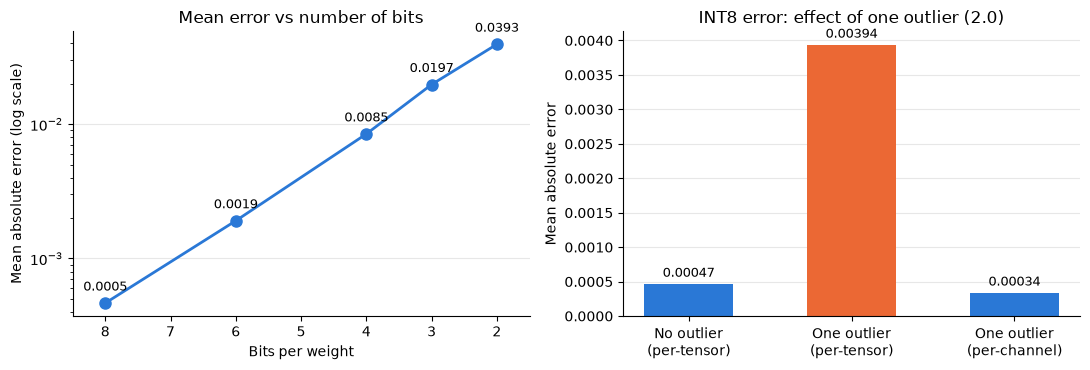

In [3]:
rng = np.random.default_rng(0)
layer = rng.normal(0, 0.05, size=(768, 768)).astype(np.float32)

bit_options = [8, 6, 4, 3, 2]
errors = [np.abs(layer - dequantize(*quantize_symmetric(layer, bits))).mean() for bits in bit_options]

# one big value makes the scale big for every other weight
outlier_layer = layer.copy()
outlier_layer[0, 0] = 2.0
q, scale = quantize_symmetric(outlier_layer, 8)
error_per_tensor = np.abs(outlier_layer - dequantize(q, scale)).mean()

# per-channel: a separate scale for each row
row_scales = np.abs(outlier_layer).max(axis=1, keepdims=True) / 127
q_rows = np.clip(np.round(outlier_layer / row_scales), -127, 127)
error_per_channel = np.abs(outlier_layer - q_rows * row_scales).mean()

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

left.plot(bit_options, errors, color="#2a78d6", linewidth=2, marker="o", markersize=8)
left.set_yscale("log")
left.set_xlim(8.5, 1.5)
for bits, error in zip(bit_options, errors):
    left.annotate(f"{error:.4f}", (bits, error), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9)
left.set_title("Mean error vs number of bits")
left.set_xlabel("Bits per weight")
left.set_ylabel("Mean absolute error (log scale)")

labels = ["No outlier\n(per-tensor)", "One outlier\n(per-tensor)", "One outlier\n(per-channel)"]
values = [errors[0], error_per_tensor, error_per_channel]
bars = right.bar(labels, values, color=["#2a78d6", "#eb6834", "#2a78d6"], width=0.55)
right.bar_label(bars, labels=[f"{v:.5f}" for v in values], padding=3, fontsize=9)
right.set_title("INT8 error: effect of one outlier (2.0)")
right.set_ylabel("Mean absolute error")

for ax in (left, right):
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

- **Left:** the line is straight on a log scale, so the error roughly **doubles for every bit removed**, as section 3.4 predicts. 8 bits is very accurate, and 2 bits is about 80 times worse.
- **Right:** a single outlier out of 589,824 weights makes the INT8 error about **8 times larger**, because it stretches the scale for everyone. Per-channel scales fix this: only the outlier's row gets a large scale.

This is exactly the main problem when quantizing LLMs (section 5).

## 4. Types of quantization

| Type | When | How | Pros / cons |
|---|---|---|---|
| **Post-training, dynamic** | after training | weights stored in INT8; activations quantized on the fly during inference | no data needed, one line of code; activations cost a little time |
| **Post-training, static** | after training | weights and activations in INT8; activation ranges measured once on a small **calibration** set | fastest on CPU; needs calibration data |
| **Quantization-aware training (QAT)** | during training | the forward pass simulates rounding ("fake quantization"), so the model learns to cope with it | best accuracy at low bits; needs full training |

In QAT, the rounding has zero gradient almost everywhere, so training uses the **straight-through estimator** (STE): it pretends the rounding was not there when computing gradients:

$$\frac{\partial \, \mathrm{round}(x)}{\partial x} \approx 1$$

## 5. Quantization for large language models (LLaMA)

Simple INT8 works well for BERT-sized models, but LLMs above about 6B parameters have a few **outlier features** with values up to 100 times larger than the rest (Dettmers et al., 2022). As Code 1 showed, outliers ruin the scale. Modern methods solve this in different ways:

| Method | Bits | Idea |
|---|---|---|
| **LLM.int8()** (bitsandbytes) | 8 | keeps the few outlier columns in FP16 and quantizes the rest to INT8 |
| **GPTQ** | 3-4 | quantizes weights one column at a time and adjusts the remaining weights to cancel the error, using a small calibration set |
| **AWQ** | 4 | finds the ~1% of weights that matter most (from activation sizes) and scales them up before quantizing, so they are protected |
| **NF4 / QLoRA** | 4 | "NormalFloat 4": the 16 levels are placed where normally distributed weights are dense; used to fine-tune LLaMA on one GPU |
| **GGUF** (llama.cpp, Ollama) | 2-8 | group-wise integer formats (for example Q4_K_M) that run LLaMA on a normal CPU or a Mac |

For example, Llama 3 8B is 16 GB in FP16 but about **5 GB** as a 4-bit GGUF file, so it runs on a laptop.
Note: bitsandbytes and GPTQ need an NVIDIA GPU, so the hands-on example below uses PyTorch's built-in quantization, which runs on any CPU.

## 6. Code 2: quantizing DistilBERT with PyTorch

`distilbert-base-uncased-finetuned-sst-2-english` is a DistilBERT model fine-tuned for sentiment (positive / negative).
`torch.ao.quantization.quantize_dynamic` applies **post-training dynamic quantization**: every `nn.Linear` layer gets INT8 weights. No training and no data are needed.
We compare file size, speed and predictions on 12 example sentences.

In [4]:
import os
import tempfile
import time

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_fp32 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).eval()

# qnnpack is the quantization engine for ARM chips like the M4
torch.backends.quantized.engine = "qnnpack"
model_int8 = torch.ao.quantization.quantize_dynamic(model_fp32, {torch.nn.Linear}, dtype=torch.qint8)


def size_mb(model):
    path = os.path.join(tempfile.gettempdir(), "temp_model.pt")
    torch.save(model.state_dict(), path)
    size = os.path.getsize(path) / 1e6
    os.remove(path)
    return size


sentences = [
    "I loved this movie, it was wonderful.",
    "The food was cold and the service was terrible.",
    "What a fantastic experience, I would go again.",
    "This is the worst product I have ever bought.",
    "The book was boring and far too long.",
    "Great acting and a beautiful story.",
    "I am not happy with this phone at all.",
    "The hotel staff were friendly and helpful.",
    "It broke after two days, a waste of money.",
    "An amazing concert, the band was brilliant.",
    "The film was okay, nothing special.",
    "I would never recommend this restaurant.",
]
true_labels = np.array([1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0])
inputs = tokenizer(sentences, padding=True, return_tensors="pt")


def run(model, repeats=20):
    with torch.no_grad():
        model(**inputs)  # warm-up
        start = time.time()
        for _ in range(repeats):
            logits = model(**inputs).logits
    milliseconds = (time.time() - start) / repeats * 1000
    return logits.softmax(dim=-1), milliseconds


probs_fp32, ms_fp32 = run(model_fp32)
probs_int8, ms_int8 = run(model_int8)

results = pd.DataFrame({
    "FP32": [size_mb(model_fp32), ms_fp32, (probs_fp32.argmax(-1).numpy() == true_labels).mean()],
    "INT8 (dynamic)": [size_mb(model_int8), ms_int8, (probs_int8.argmax(-1).numpy() == true_labels).mean()],
}, index=["Size (MB)", "Time for 12 sentences (ms)", "Accuracy on 12 sentences"])
display(results.round(3))

comparison = pd.DataFrame({
    "sentence": sentences,
    "P(positive) FP32": probs_fp32[:, 1].numpy().round(3),
    "P(positive) INT8": probs_int8[:, 1].numpy().round(3),
})
display(comparison)

/Users/nagham/Cellula_2week_Nagham_Taweel/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 11810.46it/s]


/var/folders/qz/0rjpwz2x14vbz390g041rc4m0000gn/T/ipykernel_47387/3555617595.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = torch.ao.quantization.quantize_dynamic(model_fp32, {torch.nn.Linear}, dtype=torch.qint8)


/Users/nagham/Cellula_2week_Nagham_Taweel/.venv/lib/python3.12/site-packages/torch/ao/nn/quantized/modules/utils.py:72: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/quantized/Quantizer.cpp:116.)
  qweight = torch.quantize_per_tensor(


[W1003 02:03:09.987468000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


,FP32,INT8 (dynamic)
Size (MB),267.861,138.714
Time for 12 sentences (ms),17.237,26.758
Accuracy on 12 sentences,0.917,1.000


,sentence,P(positive) FP32,P(positive) INT8
0,"I loved this movie, it was wonderful.",1.000,1.000
1,The food was cold and the service was terrible.,0.000,0.000
2,"What a fantastic experience, I would go again.",1.000,1.000
3,This is the worst product I have ever bought.,0.000,0.000
4,The book was boring and far too long.,0.000,0.000
5,Great acting and a beautiful story.,1.000,1.000
6,I am not happy with this phone at all.,0.000,0.000
7,The hotel staff were friendly and helpful.,1.000,1.000
8,"It broke after two days, a waste of money.",0.000,0.000
9,"An amazing concert, the band was brilliant.",1.000,1.000


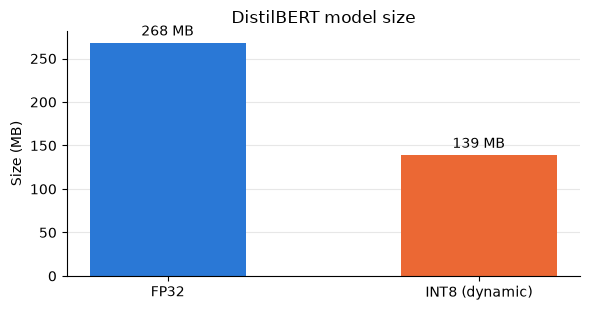

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.2))
sizes_mb = [results.loc["Size (MB)", "FP32"], results.loc["Size (MB)", "INT8 (dynamic)"]]
bars = ax.bar(["FP32", "INT8 (dynamic)"], sizes_mb, color=["#2a78d6", "#eb6834"], width=0.5)
ax.bar_label(bars, labels=[f"{v:.0f} MB" for v in sizes_mb], padding=3)
ax.set_title("DistilBERT model size")
ax.set_ylabel("Size (MB)")
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

**What the results show:**
- **Size:** the model is about **half** the size, not a quarter. Only the `Linear` layers become INT8; the embedding table (about 30,000 words $\times$ 768 numbers) stays in FP32. Quantizing the embeddings too would bring it closer to 4$\times$.
- **Predictions:** 11 of 12 sentences get the same label with almost the same probability. The one that changes is "I would never recommend this restaurant": FP32 wrongly gives it 0.93 positive, INT8 gives 0.46, which flips it to negative. So INT8 scored 12/12 here, but that is luck on one uncertain sentence, not a real improvement: quantization adds small noise, and the noise only changes the label when the model is unsure.
- **Speed:** on this Mac, INT8 was **not** faster. The M4's FP32 matrix code (Apple Accelerate) is very optimised, while dynamic quantization has to quantize the activations on every call. On typical x86 server CPUs, dynamic INT8 is usually faster. Speed gains depend on the hardware; memory savings do not.

## 7. Conclusion

- Large models are mostly weights, and memory is $N_{\text{params}} \times \frac{b}{8}$ bytes, so using fewer bits per weight shrinks a model directly: 2$\times$ with FP16, 4$\times$ with INT8, 8$\times$ with INT4.
- Quantization replaces each weight with a small integer and a shared scale. The error is at most half a step and roughly doubles with every bit removed (Code 1).
- **Outliers** are the main difficulty. Per-channel or group-wise scales, and LLM methods such as LLM.int8(), GPTQ and AWQ, are designed around them.
- In practice, **INT8** is almost free for models like BERT (Code 2: half the size, nearly the same predictions), and **4-bit** methods are what make LLaMA models usable on laptops (32 GB $\rightarrow$ about 5 GB for Llama 3 8B).
- Quantization can be combined with the other methods, for example a distilled model (DistilBERT) that is also quantized.

## References
- Jacob et al., 2018. *Quantization and Training of Neural Networks for Efficient Integer-Arithmetic-Only Inference.* arXiv:1712.05877
- Sanh et al., 2019. *DistilBERT, a distilled version of BERT.* arXiv:1910.01108
- Dettmers et al., 2022. *LLM.int8(): 8-bit Matrix Multiplication for Transformers at Scale.* arXiv:2208.07339
- Frantar et al., 2022. *GPTQ: Accurate Post-Training Quantization for Generative Pre-trained Transformers.* arXiv:2210.17323
- Lin et al., 2023. *AWQ: Activation-aware Weight Quantization for LLM Compression and Acceleration.* arXiv:2306.00978
- Dettmers et al., 2023. *QLoRA: Efficient Finetuning of Quantized LLMs.* arXiv:2305.14314
- PyTorch documentation: Quantization (`torch.ao.quantization`)